# Hands-On Project: Stellar Luminosity

## 1. Establishing environment

In [28]:
# Required libraries
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import sys
import numpy as np 
import matplotlib.pyplot as plt

# Libraries' versions
print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]
NumPy version: 2.5.1
Matplotlib version: 3.11.1



As we are using NumPy library, then we are going to load the dataset as NumPy arrays:

In [30]:
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# Shapes of the arrays
print("Mass shape:", mass.shape)
print("Luminosity shape:", luminosity.shape)

# Ranges of the variables
print("Mass range:", mass.min(), "to", mass.max())
print("Luminosity range:", luminosity.min(), "to", luminosity.max())

Mass shape: (10,)
Luminosity shape: (10,)
Mass range: 0.6 to 2.4
Luminosity range: 0.15 to 35.0


___

## 2. Exploring before modeling

We are going to plot stellar mass against luminosity

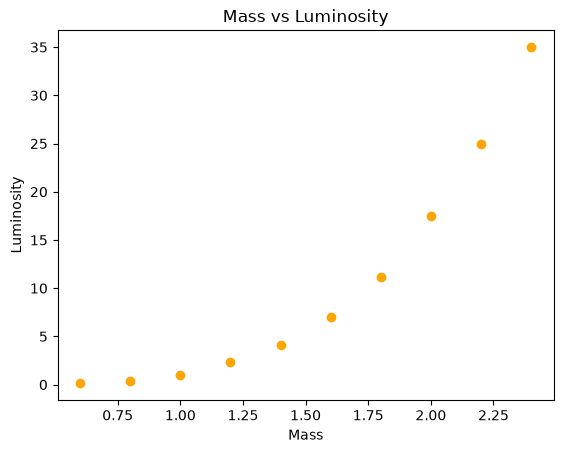

In [31]:
# First we create a new empty figure
plt.figure()

# Now we plot the data points
plt.scatter(mass, luminosity, color="orange")

# Then, we add labels and a title
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Mass vs Luminosity")

# Finally, we show the plot
plt.show()

### Describing the observed relation

The relationship between stellar mass and luminosity appears to be nonlinear. It's clear to see that as the stellar mass increases, the luminosity increases at a much faster rate, suggesting an upward-curving trend rather than a straight line.

A straight line does not appear to be adequate because it cannot fully capture the curved pattern. It would likely overestimate the luminosity of some stars and underestimate it for others, especially near the beginning and the end of the observed range. These systematic errors suggest that a nonlinear model may provide a better fit.

___

## 3. Implementing the learning algorithm

We'll use the model:

$$
f_{\vec{w}, b}(\vec{x}) = \vec{w}^T \vec{x} + b.
$$

In [32]:
def predict(X, w, b):
    return X @ w + b

We define the **mean squared error** as the cost function, just as it was made in class:

$$
J(\vec{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \right)^2.
$$



In [ ]:
def compute_cost(X, y, w, b):
    m = X.shape[0]

    errors = predict(X, w, b) - y
    cost = np.sum(errors**2) / (2*m) 
    return cost

We use **gradient descent** with the update rules:

- For each $w_j$:
  $$
  \frac{\partial J(\vec{w}, b)}{\partial w_j} 
  = \frac{1}{m} \sum_{i=1}^{m} \big( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \big)\, x_j^{(i)}.
  $$

- For the bias term $b$:
  $$
  \frac{\partial J(\vec{w}, b)}{\partial b} 
  = \frac{1}{m} \sum_{i=1}^{m} \big( f_{\vec{w}, b}(\vec{x}^{(i)}) - y^{(i)} \big).
  $$

Update:

$$
\vec{w} := \vec{w} - \alpha \, \nabla_{\vec{w}} J(\vec{w}, b),
\qquad
b := b - \alpha \, \frac{\partial J(\vec{w}, b)}{\partial b},
$$

In [34]:
def compute_gradients(X,y,w,b):
    m = X.shape[0]

    errors = predict(X, w, b) - y

    # Derivative of the cost function with respect to w
    df_dw = (X.T @ errors) / m

    # Derivative of the cost function with respect to b
    df_db = np.sum(errors) / m

    return df_dw, df_db

Now, let's implement the gradient descent loop:

In [35]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iterations):
    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        # Compute gradients
        df_dw, df_db = compute_gradients(X, y, w, b)

        # Update parameters
        w = w - alpha * df_dw
        b = b - alpha * df_db

        # Save the cost
        cost = compute_cost(X, y, w, b)
        history.append((i, cost))

        # We are going to print the cost every 100 iterations
        if i % max(1, num_iterations // 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"w = {np.round(w, 4)}, "
                f"b = {b:7.4f}, "
                f"cost = {cost:8.4f}"
            )

    return w, b, history

We can see that this functions support design matrices thanks with one or more features thanks to NumPy library

___
## 4. Training a linear model

It is time to initialize the paramenters and choose a learning rate and a number of iterations.

For linear regression, gradient descent usually converges to the same solution regardless of the starting point, because the cost function is convex. Therefore, we will use the simplest initialization by setting both parameters to zero.

We will also choose a reasonable learning rate: not too large and not too small. Finally, we will select a number of iterations that is large enough for the algorithm to converge.

In [ ]:
# Design matrix for the linear model
X_linear = mass.reshape(-1, 1) # Reshape to a column vector

w = np.zeros(X_linear.shape[1])
b = 0.0
alpha = 0.01
num_iterations = 10000

Now, we are going to train the model.

In [37]:
w_learned, b_learned, cost_history = gradient_descent(X_linear, luminosity, w, b, alpha, num_iterations)

print("Learned parameters:")
print("w = ", w_learned)
print("b = ", b_learned)

Iteration    0: w = [0.2152], b =  0.1036, cost = 112.0896
Iteration 1000: w = [13.3693], b = -8.9470, cost =  13.8142
Iteration 2000: w = [16.284], b = -13.7764, cost =  10.3996
Iteration 3000: w = [17.4143], b = -15.6491, cost =   9.8860
Iteration 4000: w = [17.8526], b = -16.3754, cost =   9.8088
Iteration 5000: w = [18.0226], b = -16.6571, cost =   9.7972
Iteration 6000: w = [18.0885], b = -16.7663, cost =   9.7955
Iteration 7000: w = [18.1141], b = -16.8086, cost =   9.7952
Iteration 8000: w = [18.124], b = -16.8251, cost =   9.7952
Iteration 9000: w = [18.1279], b = -16.8314, cost =   9.7951
Learned parameters:
w =  [18.12935781]
b =  -16.833888424078236


To make better observations we are going to plot some model training behaviors

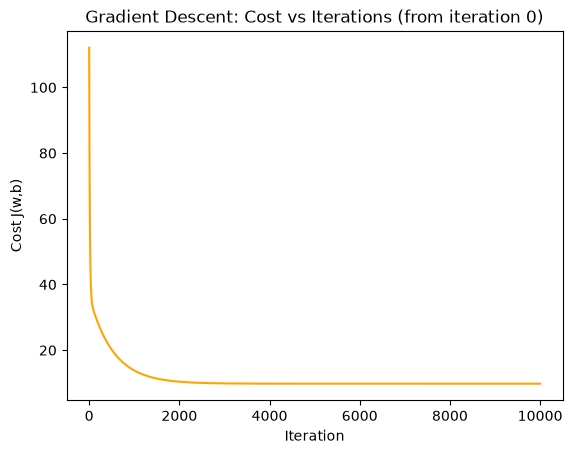

In [38]:
iterations = [it for it, c in cost_history]
cost = [c for it, c in cost_history]

# We can change this to zoom into the cost curve
start_iteration = 0

# Find the first index where the iteration is greater than or equal to start_iteration
start_index = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration:
        start_index = i
        break

fig , ax = plt.subplots()
ax.plot(iterations[start_index:], cost[start_index:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_index]})") # The iteration number is different in the workshop 3

# This keeps the labels as the actual cost values instead of scientific notation
ax.ticklabel_format(axis='y', style='plain', useOffset=False)

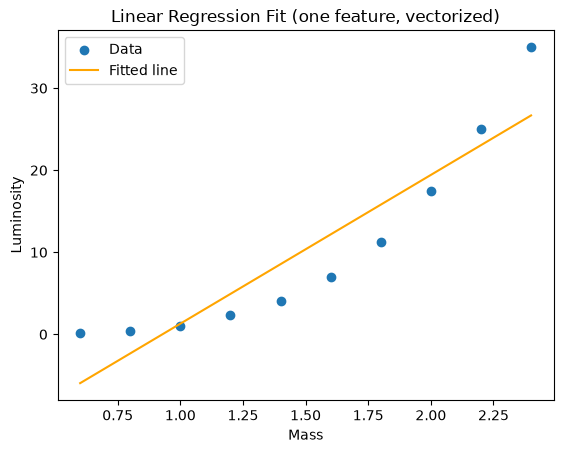

In [39]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred_linear = predict(X_linear, w_learned, b_learned)

plt.plot(mass, y_pred_linear, color="orange", label="Fitted line")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Linear Regression Fit (one feature, vectorized)")
plt.legend()
plt.show()

In [40]:
# Final parameter and cost values
print(f"Final parameters: w = {w_learned[0]}, b = {b_learned}")
print(f"Final cost: {cost_history[-1][1]}")

Final parameters: w = 18.129357806016017, b = -16.833888424078236
Final cost: 9.79514864326178


### Convergence and systematic errors

The cost decreases smoothly as the number of iterations increases, without sudden jumps or oscillations. At the beginning, the cost decreases quickly, but the changes become much smaller over time. When looking at the last iterations more closely, the cost is still decreasing, but the difference between consecutive values is very small. This indicates that gradient descent is approaching convergence and that the parameters w and b are becoming stable. The smooth behavior of the curve also suggests that the selected learning rate is appropriate. There is no visible systematic instability in the optimization process, such as repeated jumps or oscillations in the cost.


In [41]:
# Difference between the lasts costs
# Get the last 10 iterations
last_10 = cost_history[-10:]

# Compare consecutive costs
for i in range(1, len(last_10)):
    previous_iteration, previous_cost = last_10[i - 1]
    current_iteration, current_cost = last_10[i]

    difference = abs(current_cost - previous_cost)

    print(
        f"Iteration {previous_iteration} -> {current_iteration}: "
        f"cost difference = {difference:.15f}"
    )

Iteration 9990 -> 9991: cost difference = 0.000000000304999
Iteration 9991 -> 9992: cost difference = 0.000000000304414
Iteration 9992 -> 9993: cost difference = 0.000000000303841
Iteration 9993 -> 9994: cost difference = 0.000000000303269
Iteration 9994 -> 9995: cost difference = 0.000000000302695
Iteration 9995 -> 9996: cost difference = 0.000000000302117
Iteration 9996 -> 9997: cost difference = 0.000000000301551
Iteration 9997 -> 9998: cost difference = 0.000000000300972
Iteration 9998 -> 9999: cost difference = 0.000000000300407


___
## 5. Training a polynomial model

Now, we are going to create the representation

$$
\textit{X\_polinomial} = [mass, mass^{2}]
$$

In [42]:
mass_sqr = mass**2

Reusing the functions develop above we will train the polynomial model

In [50]:
# Design matrix for the polynomial model
X_polynomial = np.column_stack((mass, mass_sqr))

# The parameters initialization
w_poly = np.zeros(X_polynomial.shape[1])
b_poly = 0.0

# Training the polynomial model
alpha_poly = 0.01
iterations_poly = 100000

w_learned_poly, b_learned_poly, cost_history_poly = gradient_descent(X_polynomial, luminosity, w_poly, b_poly, alpha_poly, iterations_poly)


Iteration    0: w = [0.2152 0.4594], b =  0.1036, cost =  92.6099
Iteration 10000: w = [-12.6755  10.4376], b =  2.3882, cost =   1.2311
Iteration 20000: w = [-18.961   12.4576], b =  6.6297, cost =   0.5977
Iteration 30000: w = [-22.4519  13.5795], b =  8.9854, cost =   0.4023
Iteration 40000: w = [-24.3908  14.2027], b = 10.2938, cost =   0.3420
Iteration 50000: w = [-25.4677  14.5487], b = 11.0204, cost =   0.3234
Iteration 60000: w = [-26.0657  14.7409], b = 11.4240, cost =   0.3177
Iteration 70000: w = [-26.3979  14.8477], b = 11.6482, cost =   0.3159
Iteration 80000: w = [-26.5824  14.907 ], b = 11.7727, cost =   0.3154
Iteration 90000: w = [-26.6849  14.9399], b = 11.8418, cost =   0.3152


Let's see some training model behaviors in a graph.

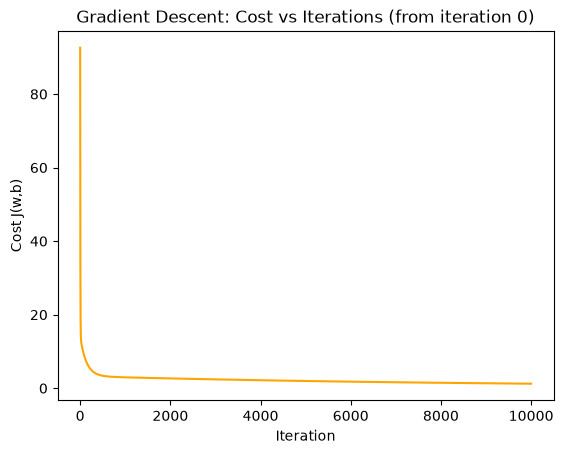

In [44]:
iterations = [it for it, c in cost_history_poly]
cost = [c for it, c in cost_history_poly]

start_iteration_poly = 0

start_index_poly = 0
for i in range(len(iterations)):
    if iterations[i] >= start_iteration_poly:
        start_index_poly = i
        break

fig, ax = plt.subplots()
ax.plot(iterations[start_index_poly:], cost[start_index_poly:], color = "orange")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost J(w,b)")
ax.set_title(f"Gradient Descent: Cost vs Iterations (from iteration {iterations[start_index_poly]})")

ax.ticklabel_format(axis='y', style='plain', useOffset=False)

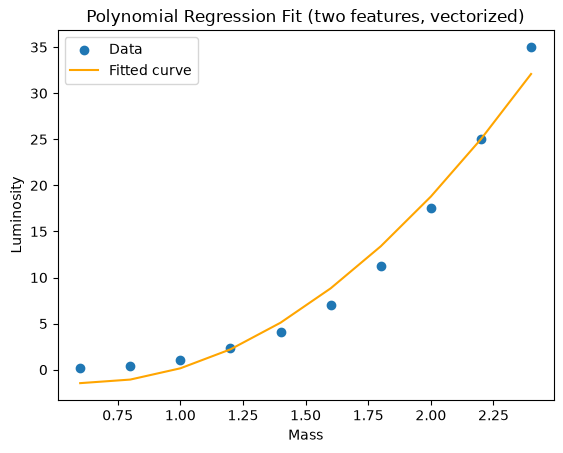

In [45]:
plt.figure()
plt.scatter(mass, luminosity, label="Data")

y_pred_poly = predict(X_polynomial, w_learned_poly, b_learned_poly)

plt.plot(mass, y_pred_poly, color="orange", label="Fitted curve")
plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Polynomial Regression Fit (two features, vectorized)")
plt.legend()
plt.show()

### What changed in the model and what remained unchanged?

In the polynomial model, the main change is the input representation. Instead of using only stellar mass as one feature, the design matrix now includes both mass and mass squared. Therefore, the model changes from a straight-line relationship to a quadratic relationship:

$$
\hat{y} = w_{1}x + w_{2}x^{2} + b
$$

This also means that the model now has two weights instead of one, because each feature has its own coefficient. The squared term gives the model the ability to represent curvature in the relationship between stellar mass and luminosity.

The training settings also had to be adjusted for the polynomial model. Since adding the squared-mass feature changes the scale of the input and the gradients, I tested a different learning rate and number of iterations to obtain stable convergence.

What remains unchanged is the general learning procedure. The same target variable, luminosity, is used; predictions are still computed from the design matrix, weights, and bias; the same cost function is minimized; and gradient descent is still used to update the parameters. The bias remains a single scalar value. In other words, the optimization method remains the same, while the feature representation and therefore the shape of the fitted model change.

___
## 6. Comparing the models

According to each model's information, we are going to make a comparison between them to make an accurate conclusion of which model represents the observed range better and why.

In [51]:
# Comparing final costs of both models
final_cost_linear = cost_history[-1][1]
final_cost_poly = cost_history_poly[-1][1]

print(f"Final cost - Linear model: {final_cost_linear}")
print(f"Final cost - Polynomial model: {final_cost_poly}")

Final cost - Linear model: 9.79514864326178
Final cost - Polynomial model: 0.31515649802559187


The polynomial model achieved a lower final training cost than the linear model. This indicates that, for the observed data used during training, the polynomial model produces predictions that are closer to the observed luminosity values according to the cost function.

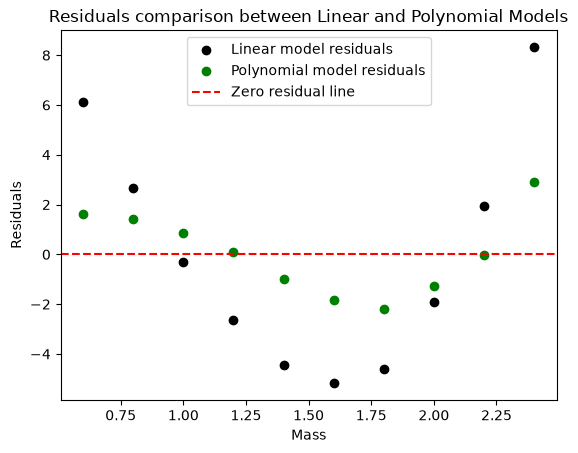

In [47]:
# Inspecting the residuals of both models
residuals_linear = luminosity - y_pred_linear
residuals_poly = luminosity - y_pred_poly

# Ploting the residuals for both models
plt.figure();

plt.scatter(mass, residuals_linear, color="black", label="Linear model residuals")
plt.scatter(mass, residuals_poly, color="green", label="Polynomial model residuals")

plt.axhline(0, color="red", linestyle="--", label="Zero residual line")

plt.xlabel("Mass")
plt.ylabel("Residuals")
plt.title("Residuals comparison between Linear and Polynomial Models")
plt.legend()
plt.show()



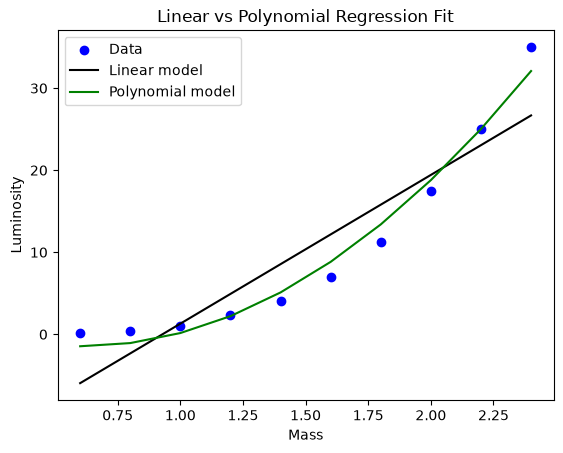

In [48]:
# Both fitted models with the observations

plt.figure()

plt.scatter(mass, luminosity, color="blue", label="Data",)
plt.plot(mass, y_pred_linear, color="black", label="Linear model")
plt.plot(mass, y_pred_poly, color="green", label="Polynomial model")

plt.xlabel("Mass")
plt.ylabel("Luminosity")
plt.title("Linear vs Polynomial Regression Fit")
plt.legend()
plt.show()


In this graph, we can see more clearly how both models fit the observations. The linear model follows the general trend, but the straight line cannot capture the curved shape of the data very well. The polynomial model follows the observations more closely because it can represent that curvature. Therefore, for this observed range, the polynomial model seems to be a better fit.

### Which model represents the observed range better and why?
Over the observed mass range, the polynomial model represents the data better than the linear model. Its fitted curve follows the increasing curvature of the observations more closely, while the linear model is constrained to a straight line and therefore systematically misses parts of the relationship. The polynomial model also obtains a lower training cost and generally smaller residuals. Together, these results indicate that the polynomial representation provides a better description of the observed data.

## 7. Testing the boundary of the evidence

We are going to generate predictions from both models for:

- $mass = 1.3$, inside the observed range.
- $mass = 5.0$, far outside the observed range.

In [49]:
test_masses = np.array([1.3, 5.0])

X_test_linear = test_masses.reshape(-1, 1)
# Predicting luminosity for the test masses using linear model
y_test_linear = predict(X_test_linear, w_learned, b_learned)

X_test_polynomial = np.column_stack((test_masses, test_masses**2))
# Predicting luminosity for the test masses using polynomial model
y_test_poly = predict(X_test_polynomial, w_learned_poly, b_learned_poly)

# Displaying the predictions
for mass_value, linear_pred, poly_pred in zip(
    test_masses,
    y_test_linear,
    y_test_poly
):
    print(f"Mass = {mass_value:.1f}")
    print(f"Linear prediction: {linear_pred:.4f}")
    print(f"Polynomial prediction: {poly_pred:.4f}")
    print()


Mass = 1.3
Linear prediction: 6.7343
Polynomial prediction: 3.5496

Mass = 5.0
Linear prediction: 73.8129
Polynomial prediction: 199.9471



The prediction for mass 1.3 is better supported by the available evidence because it is an interpolation within the observed range. In contrast, mass 5.0 requires extrapolation far beyond the available observations. The large difference between the linear and polynomial predictions at 5.0 illustrates how models that may fit the observed data reasonably well can behave very differently outside that range. Therefore, the dataset does not provide sufficient evidence to strongly trust either prediction at mass 5.0.

___
## 8. Reflecting on Artificial Intelligence

**a) What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?**

This regression experiment shows me that a model can learn by adjusting its parameters according to its errors. In our case, gradient descent changed w and b little by little to reduce the cost. I also found interesting that a model can learn correctly and still not be a good representation of reality. For example, our linear model learned the best parameters it could for a straight line, but a straight line was simply not flexible enough to represent the curve in the data. When we added mass squared, we gave the model a better representation and it was able to fit the observations better.

However, this experiment does not explain everything about how advanced AI systems learn. Our model has very few parameters, one specific objective and a very simple mathematical structure. Modern AI systems can have billions of parameters and learn much more complex representations from enormous amounts of data. Still, the experiment gives us a basic idea that is also present in more advanced machine learning: make predictions, measure errors and adjust parameters to improve performance. It does not explain by itself how abilities such as language, reasoning, planning or generalization emerge in much larger systems.


**b) Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.**

I understand AGI as an AI system that would be able to learn, reason and perform successfully across a very wide range of intellectual tasks, instead of being designed mainly for specific types of problems. It can match or exceed the cognitive abilities of human being across any task.

Personally, I am not convinced that AGI will be achieved soon. I think there are still important things that we don't understand about intelligence itself. We don't completely understand how the human brain produces reasoning, consciousness, intentions or our ability to learn from relatively little experience. A baby, for example, does not begin life with a huge database of written information, but gradually develops an understanding of the world through perception, interaction and learning.

Because of this, I find it difficult to believe that simply giving an AI more information will necessarily produce general intelligence. AGI may be achievable eventually, but I think we may need a deeper understanding of learning and intelligence before reaching it.


**c) Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?**

I don't think that AGI will necessarily emerge only by adding more GPUs, data and parameters to current neural networks. Scaling clearly matters: larger models, more data and more computation have produced major improvements in AI. Research on neural scaling laws has shown that performance can improve predictably as model size, data and computation increase.

However, our regression experiment gives me a simple reason to question whether scaling alone is enough. We could have trained the linear model for many more iterations, but it would always remain a straight line. To represent the curvature of the data, we had to change what the model was capable of representing by adding another feature. In a much more complex way, I think AGI may also require more than simply making today's systems bigger.

It may require different architectures or learning mechanisms, better memory and reasoning, continuous learning, interaction with the physical or social world, or ideas about intelligence that we have not discovered yet. I also think that understanding the human brain could provide important clues, although an artificial general intelligence would not necessarily have to work exactly like a human brain.

For that reason, my position is that scaling will probably remain an important part of AI progress, but I am not convinced that scaling alone will be sufficient to produce AGI.


**d) One question about AI-driven systems that I want to explore during the semester is:**

One question about AI-driven systems that I want to explore during the semester is: Can AI systems contribute to original mathematical discovery, instead of only solving problems using methods and theorems that are already known?

I am especially interested in the use of AI for solving difficult mathematical problems. I have previously tried to explore problems related to polygonal billiards, but I found that even understanding how to approach them can become extremely difficult. What interests me is not only whether an AI can calculate faster than a person, but whether it can identify patterns, propose new strategies, connect ideas that have not been connected before, or even help find a proof. There are already important projects, such as those developed by DeepMind, that use AI for mathematical reasoning and discovery. During the semester, I would like to understand whether these systems are really discovering mathematical ideas or whether they are mainly combining and extending knowledge that humans have already provided.

## References
*MindStudio. (2026, 12 junio). AI Scaling Laws Are Breaking Down: What It Means for AI Builders. MindStudio. https://www.mindstudio.ai/blog/ai-scaling-laws-breaking-down-what-it-means-for-builders*


*What is Artificial General Intelligence (AGI)? | IBM. (s. f.). https://www.ibm.com/think/topics/artificial-general-intelligence*